# 📊 Analyse Exploratoire des Données (EDA)
## Student Mental Health Prediction
### Objectif
L'objectif de cette phase est d'explorer le jeu de données afin de mieux comprendre sa structure, d'évaluer sa qualité, d'identifier les relations entre les variables et de dégager les premiers enseignements avant la phase de préparation des données et de modélisation.



In [1]:
#  Importation des bibliothèques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#importer la dataset
df = pd.read_csv("../dataset/raw/student_depression_dataset.csv")

## 1. Analyse de la qualité des données
Objectif:
Évaluer la qualité du jeu de données avant toute analyse approfondie ou modélisation.
Cette étape permettra de vérifier :
- la présence de valeurs manquantes ;
- la présence de doublons ;
- la cohérence des types de données ;
- la cohérence des valeurs ;
- la présence éventuelle de valeurs aberrantes.

In [3]:
#identifions les variables contenant les valeurs manquantes
vals_manquantes=df.isnull().sum()
vals_manquantes


id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [4]:
# Pourcentage de valeurs manquantes
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

id                                       0.0
Gender                                   0.0
Age                                      0.0
City                                     0.0
Profession                               0.0
Academic Pressure                        0.0
Work Pressure                            0.0
CGPA                                     0.0
Study Satisfaction                       0.0
Job Satisfaction                         0.0
Sleep Duration                           0.0
Dietary Habits                           0.0
Degree                                   0.0
Have you ever had suicidal thoughts ?    0.0
Work/Study Hours                         0.0
Financial Stress                         0.0
Family History of Mental Illness         0.0
Depression                               0.0
dtype: float64

In [5]:
missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": round((df.isnull().sum()/len(df))*100,2)
})

missing_data.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage (%)
id,0,0.0
Gender,0,0.0
Age,0,0.0
City,0,0.0
Profession,0,0.0
Academic Pressure,0,0.0
Work Pressure,0,0.0
CGPA,0,0.0
Study Satisfaction,0,0.0
Job Satisfaction,0,0.0


In [6]:
# Analyse des doublons
duplicates=df.duplicated().sum() #nbre de duplication
duplicates


np.int64(0)


Aucune observation dupliquée n'a été détectée dans le dataset.

In [7]:
#Comprendre la structure du dataset
df.shape

(27901, 18)

In [8]:
#séparation des variables catégorielles et numériques
categorical_columns = df.select_dtypes(include="object").columns.tolist()

numerical_columns = df.select_dtypes(include=["int64","float64"]).columns.tolist()

print("Variables catégorielles :", len(categorical_columns))
print(categorical_columns)

print()

print("Variables numériques :", len(numerical_columns))
print(numerical_columns)

Variables catégorielles : 9
['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Family History of Mental Illness']

Variables numériques : 9
['id', 'Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Depression']


C:\Users\Hp\AppData\Local\Temp\ipykernel_14080\4253482298.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


##  Interprétation
Le dataset contient des variables numériques et des variables catégorielles.
Les variables numériques permettront d'étudier les distributions, les statistiques descriptives et les valeurs aberrantes.
Les variables catégorielles permettront d'analyser la répartition des différentes modalités et leur relation avec la variable cible.

#Analyse univariée
#Variable cible : Depression

#Objectif
L'objectif de cette première analyse est d'étudier la répartition de la variable cible **Depression**.

Cette étape permet de vérifier si les classes sont équilibrées ou déséquilibrées avant la phase de modélisation.

La compréhension de cette répartition est essentielle, car elle influence le choix des modèles de Machine Learning ainsi que les métriques d'évaluation.

In [9]:
#repartition de la variable cible
df["Depression"].value_counts()

Depression
1    16336
0    11565
Name: count, dtype: int64

In [10]:
#le pourcentage du depression
round(df["Depression"].value_counts(normalize=True) * 100, 2)

Depression
1    58.55
0    41.45
Name: proportion, dtype: float64

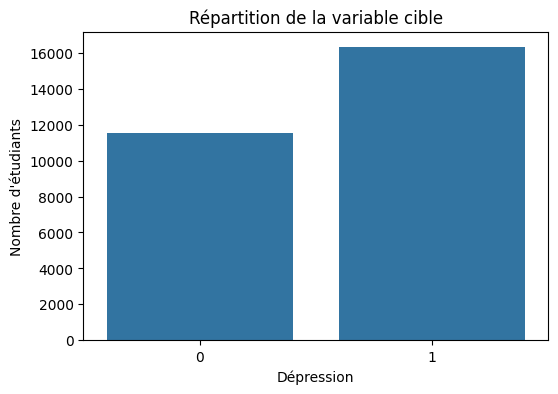

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Depression"
)

plt.title("Répartition de la variable cible")
plt.xlabel("Dépression")
plt.ylabel("Nombre d'étudiants")

plt.show()

In [12]:
# Analyse de la variable explicative : Gender
gender_counts = df["Gender"].value_counts()

gender_counts

Gender
Male      15547
Female    12354
Name: count, dtype: int64

In [13]:
round(df["Gender"].value_counts(normalize=True) * 100, 2)

Gender
Male      55.72
Female    44.28
Name: proportion, dtype: float64

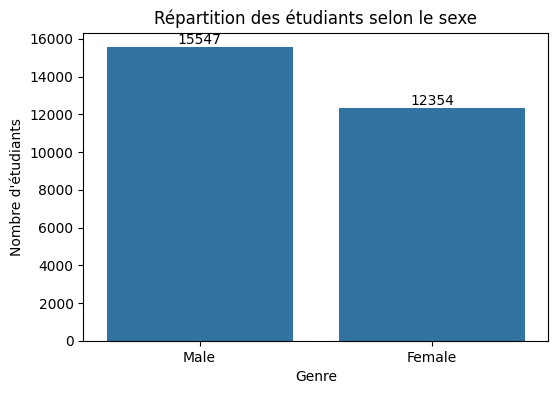

In [14]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Gender",
    order=df["Gender"].value_counts().index
)

ax.bar_label(ax.containers[0])

plt.title("Répartition des étudiants selon le sexe")
plt.xlabel("Genre")
plt.ylabel("Nombre d'étudiants")

plt.show()

# 🎂 Analyse de la variable : Age
## Objectif
L'objectif de cette analyse est d'étudier la distribution de l'âge des étudiants présents dans le jeu de données.
Cette étape permettra de mieux comprendre le profil de la population étudiée, d'identifier les principales tendances et de détecter d'éventuelles valeurs aberrantes.

In [17]:
age_stats = df["Age"].describe().to_frame()

age_stats

,Age
count,27901.000000
mean,25.822300
std,4.905687
min,18.000000
25%,21.000000
50%,25.000000
75%,30.000000
max,59.000000


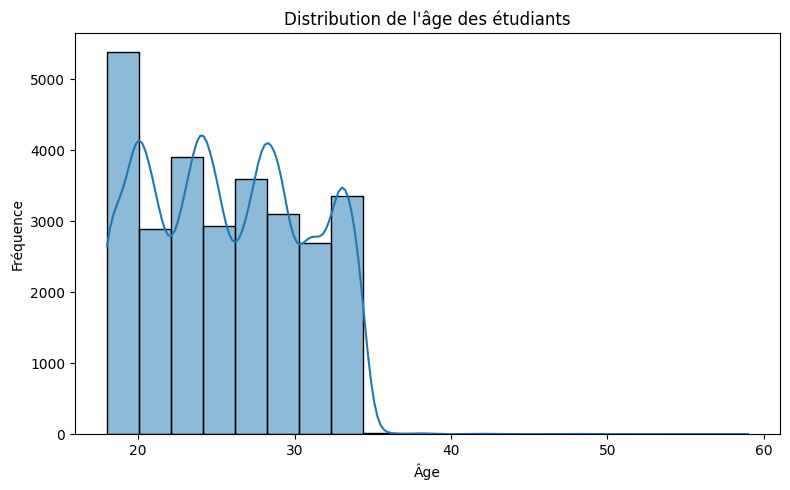

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True
)

plt.title("Distribution de l'âge des étudiants")
plt.xlabel("Âge")
plt.ylabel("Fréquence")

plt.tight_layout()
plt.show()

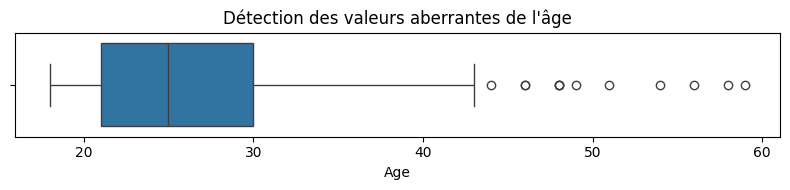

In [21]:
plt.figure(figsize=(8,2))

sns.boxplot(
    data=df,
    x="Age"
)

plt.title("Détection des valeurs aberrantes de l'âge")

plt.tight_layout()
plt.show()

## 📌 Interprétation
L'analyse de la variable **Age** montre que le jeu de données contient **27 901 étudiants**, avec un âge moyen de **25,82 ans**. Les âges varient entre **18 et 59 ans**, ce qui indique que le dataset regroupe principalement de jeunes adultes, tout en incluant quelques étudiants plus âgés.

L'histogramme montre que la majorité des observations est concentrée entre **20 et 30 ans**, ce qui correspond au profil habituel des étudiants de l'enseignement supérieur.

Le boxplot met en évidence plusieurs **valeurs aberrantes** situées au-delà d'environ **43 ans**. Ces observations correspondent à des étudiants plus âgés que la majorité de la population. Toutefois, ces valeurs restent réalistes et peuvent représenter des étudiants en reprise d'études, des étudiants en formation continue ou des doctorants. Elles ne seront donc pas considérées comme des erreurs de saisie à ce stade du projet.

Dans l'ensemble, la variable **Age** présente une distribution cohérente et ne nécessite pas de traitement particulier avant les étapes suivantes de l'analyse.

# 🏙️ Analyse de la variable : City
## Objectif
Cette analyse vise à étudier la répartition des étudiants selon leur ville de résidence ou d'étude.
Elle permettra d'identifier les villes les plus représentées dans le jeu de données et d'évaluer la diversité géographique de la population étudiée.

In [23]:
#Combien de villes différentes existe-t-il ?
df["City"].nunique()

52

In [24]:
city_counts = df["City"].value_counts()

city_counts

City
Kalyan                  1570
Srinagar                1372
Hyderabad               1340
Vasai-Virar             1290
Lucknow                 1155
Thane                   1139
Ludhiana                1111
Agra                    1094
Surat                   1078
Kolkata                 1066
Jaipur                  1036
Patna                   1007
Visakhapatnam            969
Pune                     968
Ahmedabad                951
Bhopal                   934
Chennai                  885
Meerut                   825
Rajkot                   816
Delhi                    768
Bangalore                767
Ghaziabad                745
Mumbai                   699
Vadodara                 694
Varanasi                 685
Nagpur                   651
Indore                   643
Kanpur                   609
Nashik                   547
Faridabad                461
Saanvi                     2
Bhavna                     2
City                       2
Harsha                     2
M.Tech   

In [25]:
city_counts.head(10)

City
Kalyan         1570
Srinagar       1372
Hyderabad      1340
Vasai-Virar    1290
Lucknow        1155
Thane          1139
Ludhiana       1111
Agra           1094
Surat          1078
Kolkata        1066
Name: count, dtype: int64

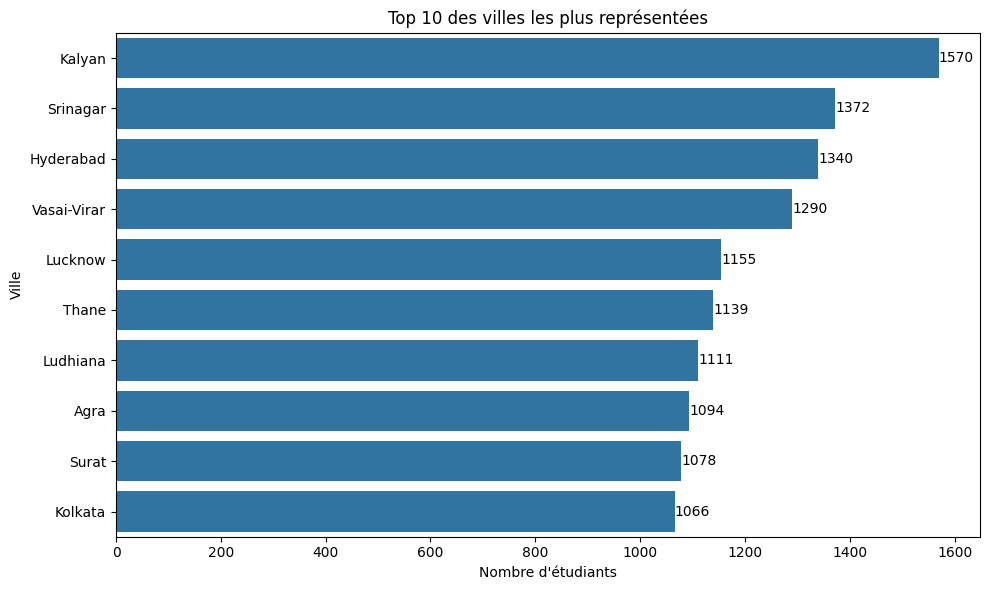

In [26]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    y="City",
    order=df["City"].value_counts().head(10).index
)

ax.bar_label(ax.containers[0])

plt.title("Top 10 des villes les plus représentées")
plt.xlabel("Nombre d'étudiants")
plt.ylabel("Ville")

plt.tight_layout()

plt.show()

##  Interprétation

L'analyse de la variable **City** montre que le jeu de données couvre **52 villes différentes**, ce qui traduit une bonne diversité géographique des étudiants.

Les villes les plus représentées sont **Kalyan**, **Srinagar**, **Hyderabad**, **Vasai-Virar** et **Lucknow**. Aucune ville ne semble dominer très largement le jeu de données, ce qui indique une répartition relativement équilibrée des observations entre les principales villes.

La variable **City** présente une **forte cardinalité** (52 modalités). Cette caractéristique devra être prise en compte lors de la phase de prétraitement des données, notamment pour le choix de la méthode d'encodage des variables catégorielles.

À ce stade, aucune décision de suppression ou de transformation n'est prise. La pertinence de cette variable sera réévaluée lors des analyses bivariées et de la phase de modélisation.

#  Analyse de la variable : Academic Pressure

## Objectif

Cette analyse vise à étudier la répartition des niveaux de pression académique déclarés par les étudiants.

Comprendre cette variable est essentiel, car la pression académique est souvent considérée comme un facteur pouvant influencer le bien-être psychologique et les performances des étudiants.

In [27]:
academic_counts = df["Academic Pressure"].value_counts().sort_index()

academic_counts

Academic Pressure
0.0       9
1.0    4801
2.0    4178
3.0    7462
4.0    5155
5.0    6296
Name: count, dtype: int64

In [28]:
academic_percentages = round(
    df["Academic Pressure"].value_counts(normalize=True)
    .sort_index() * 100,
    2
)

academic_percentages

Academic Pressure
0.0     0.03
1.0    17.21
2.0    14.97
3.0    26.74
4.0    18.48
5.0    22.57
Name: proportion, dtype: float64

In [29]:
academic_table = pd.DataFrame({
    "Nombre": academic_counts,
    "Pourcentage (%)": academic_percentages
})

academic_table

,Nombre,Pourcentage (%)
Academic Pressure,,
0.0,9,0.03
1.0,4801,17.21
2.0,4178,14.97
3.0,7462,26.74
4.0,5155,18.48
5.0,6296,22.57


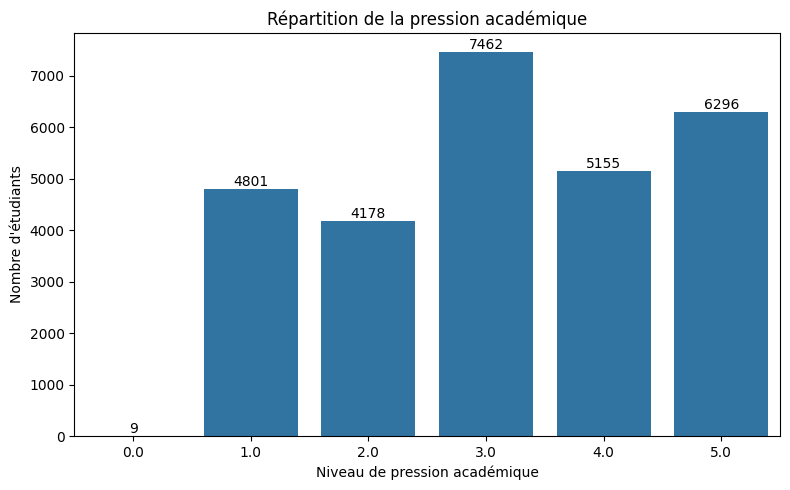

In [30]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Academic Pressure",
    order=sorted(df["Academic Pressure"].unique())
)

ax.bar_label(ax.containers[0])

plt.title("Répartition de la pression académique")
plt.xlabel("Niveau de pression académique")
plt.ylabel("Nombre d'étudiants")

plt.tight_layout()
plt.show()

## Interprétation

L'analyse de la variable **Academic Pressure** montre que la majorité des étudiants déclarent un niveau de pression académique compris entre **3 et 5**.

Le niveau **3** est le plus représenté avec **7 462 étudiants (26,74 %)**, suivi du niveau **5 (22,57 %)** puis du niveau **4 (18,48 %)**. Les niveaux de pression faibles (1 et 2) sont moins fréquents.

On observe également la présence de **9 observations** correspondant au niveau **0**. Cette valeur étant inhabituelle pour une échelle allant généralement de **1 à 5**, elle sera examinée plus en détail lors de la phase de prétraitement afin de déterminer s'il s'agit d'une valeur valide ou d'une anomalie.

Dans l'ensemble, cette variable suggère qu'une proportion importante des étudiants ressent une pression académique modérée à élevée. Son influence potentielle sur la dépression sera étudiée dans l'analyse bivariée.

#  Analyse de la variable : Study Satisfaction
## Objectif
Cette analyse vise à étudier le niveau de satisfaction des étudiants vis-à-vis de leurs études. Cette variable pourrait avoir une influence sur le risque de dépression.

In [31]:
study_counts = df["Study Satisfaction"].value_counts().sort_index()

study_percentages = round(
    df["Study Satisfaction"].value_counts(normalize=True)
    .sort_index()*100,2
)

study_table = pd.DataFrame({
    "Nombre":study_counts,
    "Pourcentage (%)":study_percentages
})

study_table

,Nombre,Pourcentage (%)
Study Satisfaction,,
0.0,10,0.04
1.0,5451,19.54
2.0,5838,20.92
3.0,5821,20.86
4.0,6359,22.79
5.0,4422,15.85


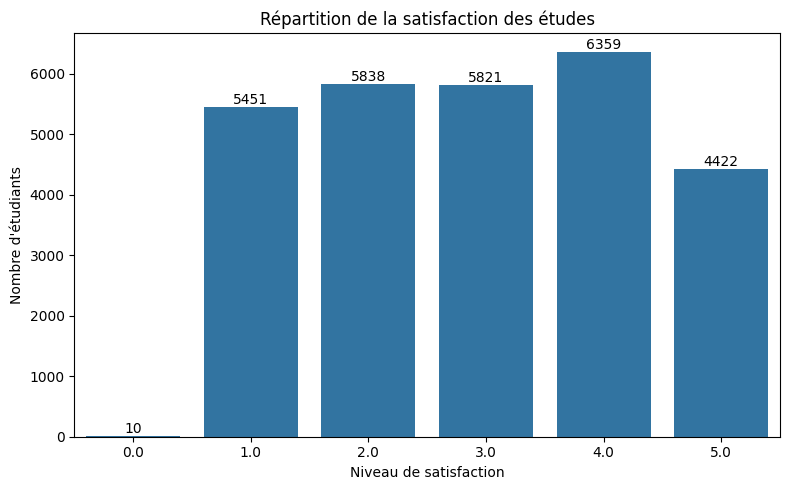

In [32]:
plt.figure(figsize=(8,5))

ax=sns.countplot(
    data=df,
    x="Study Satisfaction",
    order=sorted(df["Study Satisfaction"].unique())
)

ax.bar_label(ax.containers[0])

plt.title("Répartition de la satisfaction des études")
plt.xlabel("Niveau de satisfaction")
plt.ylabel("Nombre d'étudiants")

plt.tight_layout()
plt.show()

## Interprétation
Cette analyse montre la répartition des niveaux de satisfaction des étudiants concernant leurs études. Les niveaux les plus représentés correspondent à  2 ,3 et 4 

La présence d'étudiants ayant une faible satisfaction pourrait constituer un facteur associé au risque de dépression. Cette hypothèse sera étudiée lors des analyses bivariées.

#  Analyse de la variable : CGPA

## Objectif

Étudier la distribution des résultats académiques des étudiants.

In [33]:
df["CGPA"].describe().to_frame()

,CGPA
count,27901.000000
mean,7.656104
std,1.470707
min,0.000000
25%,6.290000
50%,7.770000
75%,8.920000
max,10.000000


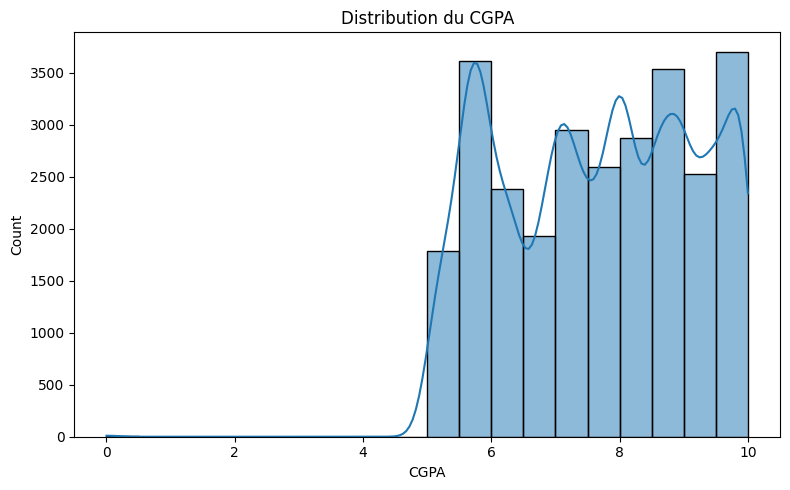

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="CGPA",
    bins=20,
    kde=True
)

plt.title("Distribution du CGPA")

plt.tight_layout()
plt.show()

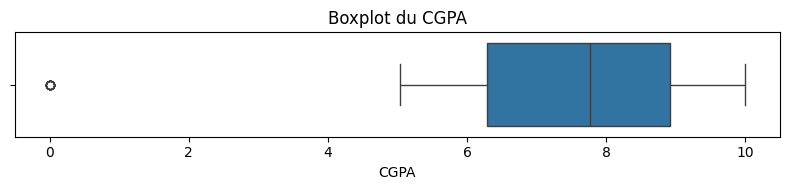

In [35]:
plt.figure(figsize=(8,2))

sns.boxplot(
    data=df,
    x="CGPA"
)

plt.title("Boxplot du CGPA")

plt.tight_layout()
plt.show()

In [36]:
df["Profession"].nunique()

14

In [37]:
profession_counts=df["Profession"].value_counts()

profession_counts

Profession
Student                     27870
Architect                       8
Teacher                         6
'Digital Marketer'              3
'Content Writer'                2
Chef                            2
Doctor                          2
Pharmacist                      2
'Civil Engineer'                1
'UX/UI Designer'                1
'Educational Consultant'        1
Manager                         1
Lawyer                          1
Entrepreneur                    1
Name: count, dtype: int64

In [38]:
profession_counts.head(10)

Profession
Student               27870
Architect                 8
Teacher                   6
'Digital Marketer'        3
'Content Writer'          2
Chef                      2
Doctor                    2
Pharmacist                2
'Civil Engineer'          1
'UX/UI Designer'          1
Name: count, dtype: int64

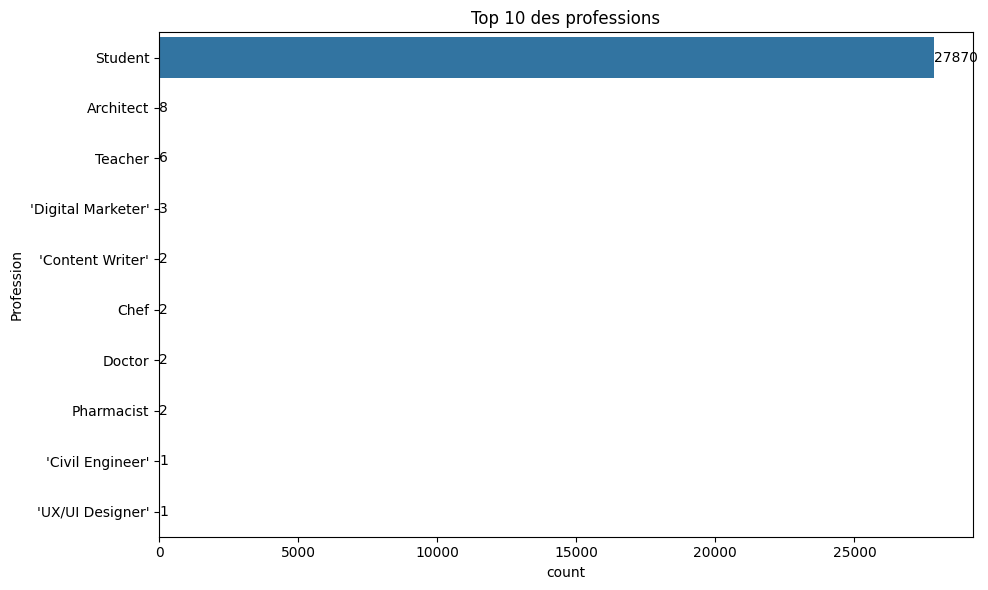

In [39]:
plt.figure(figsize=(10,6))

ax=sns.countplot(
    data=df,
    y="Profession",
    order=df["Profession"].value_counts().head(10).index
)

ax.bar_label(ax.containers[0])

plt.title("Top 10 des professions")

plt.tight_layout()

plt.show()

#  Analyse de la variable : Financial Stress

## Objectif

Cette analyse vise à étudier le niveau de stress financier déclaré par les étudiants.

Le stress financier est reconnu comme un facteur pouvant affecter la santé mentale et le bien-être. Cette variable pourrait donc jouer un rôle important dans la prédiction de la dépression.

In [42]:
financial_counts = df["Financial Stress"].value_counts().sort_index()

financial_percentages = round(
    df["Financial Stress"]
    .value_counts(normalize=True)
    .sort_index()*100,
    2
)

financial_table = pd.DataFrame({
    "Nombre": financial_counts,
    "Pourcentage (%)": financial_percentages
})

financial_table

,Nombre,Pourcentage (%)
Financial Stress,,
1.0,5121,18.35
2.0,5061,18.14
3.0,5226,18.73
4.0,5775,20.70
5.0,6715,24.07
?,3,0.01


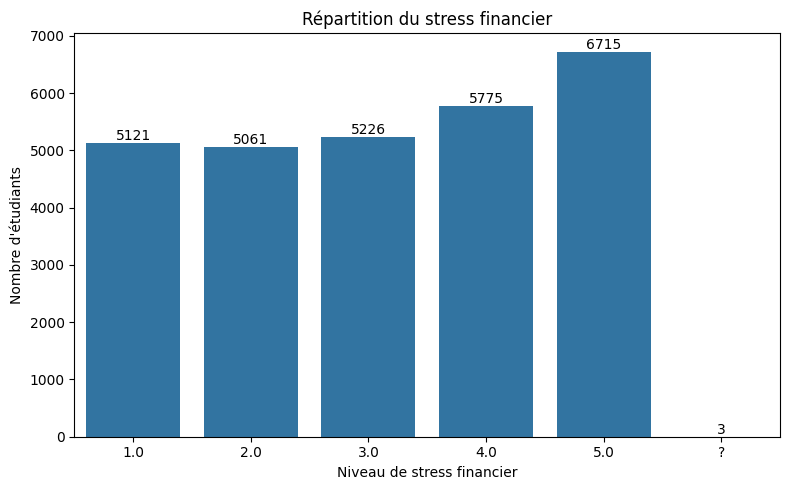

In [43]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Financial Stress",
    order=sorted(df["Financial Stress"].unique())
)

ax.bar_label(ax.containers[0])

plt.title("Répartition du stress financier")
plt.xlabel("Niveau de stress financier")
plt.ylabel("Nombre d'étudiants")

plt.tight_layout()
plt.show()

In [45]:
df["Financial Stress"].unique()

<ArrowStringArray>
['1.0', '2.0', '5.0', '3.0', '4.0', '?']
Length: 6, dtype: str

In [46]:
df[df["Financial Stress"] == '?']

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
4458,22377,Female,32.0,Varanasi,Student,3.0,0.0,5.64,1.0,0.0,'5-6 hours',Healthy,BCA,No,12.0,?,No,1
13596,68910,Male,29.0,Hyderabad,Student,2.0,0.0,8.94,3.0,0.0,'Less than 5 hours',Unhealthy,B.Ed,No,12.0,?,Yes,0
19266,97610,Female,20.0,Kolkata,Student,1.0,0.0,6.83,1.0,0.0,'5-6 hours',Healthy,MBBS,No,9.0,?,Yes,0


### Remarque

Lors de cette analyse, une modalité inattendue (`?`) a été détectée dans la variable **Financial Stress**. Cette valeur ne correspond pas à un niveau de stress valide et sera considérée comme une valeur manquante lors de la phase de préparation des données. Aucun traitement n'est appliqué à ce stade afin de préserver les données originales pendant l'analyse exploratoire.

#  Analyse de la variable : Have you ever had suicidal thoughts ?
## Objectif

Cette analyse vise à étudier la répartition des étudiants ayant déclaré avoir déjà eu des pensées suicidaires.

Cette variable est particulièrement importante dans le cadre de ce projet, car elle peut être fortement associée au risque de dépression. Son influence sera étudiée plus en détail lors de l'analyse bivariée.

In [47]:
suicidal_counts = df["Have you ever had suicidal thoughts ?"].value_counts()
suicidal_percentages = round(
    df["Have you ever had suicidal thoughts ?"]
    .value_counts(normalize=True) * 100,
    2
)
suicidal_table=pd.DataFrame({
    "Nombre": suicidal_counts,
    "Pourcentage (%)": suicidal_percentages
})
suicidal_table


,Nombre,Pourcentage (%)
Have you ever had suicidal thoughts ?,,
Yes,17656,63.28
No,10245,36.72


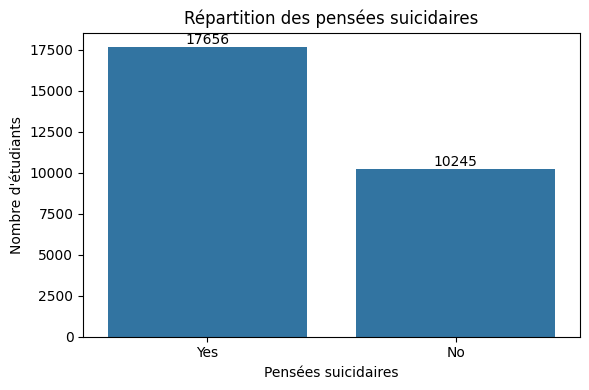

In [49]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Have you ever had suicidal thoughts ?"
)

ax.bar_label(ax.containers[0])

plt.title("Répartition des pensées suicidaires")
plt.xlabel("Pensées suicidaires")
plt.ylabel("Nombre d'étudiants")

plt.tight_layout()
plt.show()

## Interprétation

L'analyse de la variable **Have you ever had suicidal thoughts ?** montre que

La majorité des étudiants ont répondu **yes**, tandis que **36.72 %** ont déclaré avoir déjà eu des pensées suicidaires.

Cette variable présente une importance particulière dans le contexte de ce projet, car elle pourrait être fortement associée au risque de dépression. Cette hypothèse sera vérifiée lors de l'analyse bivariée.

# Analyse bivariée

## Objectif

L'analyse bivariée vise à étudier la relation entre chaque variable explicative et la variable cible **Depression**.

Cette étape permet d'identifier les facteurs susceptibles d'être associés à la dépression, de formuler des hypothèses et de sélectionner les variables les plus pertinentes avant la phase de modélisation.

# Academic Pressure vs Depression

## Objectif

Étudier la relation entre le niveau de pression académique et la présence d'une dépression.

Cette analyse permettra de vérifier si une augmentation de la pression académique semble être associée à un risque plus élevé de dépression.

In [50]:
academic_vs_depression = pd.crosstab(
    df["Academic Pressure"],
    df["Depression"]
)

academic_vs_depression

Depression,0,1
Academic Pressure,,
0.0,5,4
1.0,3869,932
2.0,2612,1566
3.0,2973,4489
4.0,1230,3925
5.0,876,5420


In [51]:
academic_vs_depression_percent = pd.crosstab(
    df["Academic Pressure"],
    df["Depression"],
    normalize="index"
) * 100

academic_vs_depression_percent.round(2)

Depression,0,1
Academic Pressure,,
0.0,55.56,44.44
1.0,80.59,19.41
2.0,62.52,37.48
3.0,39.84,60.16
4.0,23.86,76.14
5.0,13.91,86.09


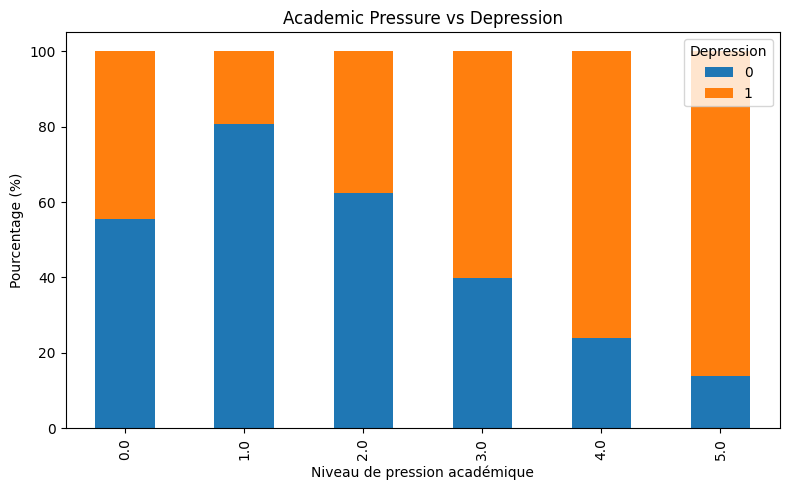

In [54]:
academic_vs_depression_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Academic Pressure vs Depression")
plt.xlabel("Niveau de pression académique")
plt.ylabel("Pourcentage (%)")

plt.legend(title="Depression")

plt.tight_layout()

plt.show()

## Interprétation

L'analyse croisée entre **Academic Pressure** et **Depression** met en évidence une relation apparente entre le niveau de pression académique et le risque de dépression.

On observe que la proportion d'étudiants souffrant de dépression augmente progressivement lorsque le niveau de pression académique augmente. À l'inverse, les étudiants déclarant un faible niveau de pression académique présentent une proportion plus importante de non-dépression.

Les niveaux de pression académique les plus élevés (4 et 5) semblent être associés à une fréquence plus importante de dépression, tandis que le niveau 1 présente la proportion la plus faible d'étudiants dépressifs.

Ces résultats suggèrent que la pression académique pourrait constituer un facteur explicatif important de la dépression chez les étudiants. Toutefois, cette observation reste descriptive et ne permet pas d'établir une relation de causalité.

Cette variable apparaît comme un bon candidat pour la phase de modélisation et sera conservée parmi les variables explicatives du modèle de Machine Learning.

## Study satisfaction vs Depression

## Objectif

Étudier la relation entre le niveau de satifaction des etudes et la présence d'une dépression.

Cette analyse permettra de vérifier si une augmentation de satisfaction des etudes semble être associée à un risque plus élevé de dépression.

In [58]:
study_vs_depression = pd.crosstab(
    df["Study Satisfaction"],
    df["Depression"]
)
study_vs_depression



Depression,0,1
Study Satisfaction,,
0.0,4,6
1.0,1594,3857
2.0,2070,3768
3.0,2468,3353
4.0,3095,3264
5.0,2334,2088


In [60]:
study_vs_depression_percent=pd.crosstab(df["Study Satisfaction"],df["Depression"],normalize="index")*100
study_vs_depression_percent.round(2)

Depression,0,1
Study Satisfaction,,
0.0,40.00,60.00
1.0,29.24,70.76
2.0,35.46,64.54
3.0,42.40,57.60
4.0,48.67,51.33
5.0,52.78,47.22


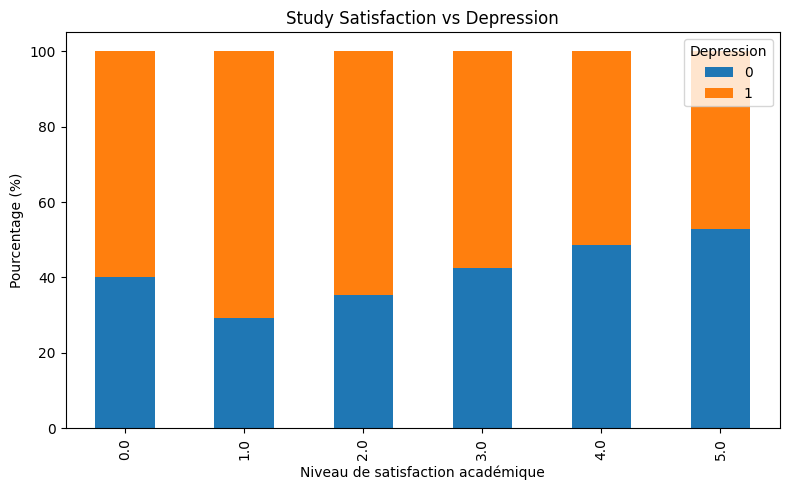

In [62]:
study_vs_depression_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Study Satisfaction vs Depression")
plt.xlabel("Niveau de satisfaction académique")
plt.ylabel("Pourcentage (%)")

plt.legend(title="Depression")

plt.tight_layout()

plt.show()

In [ ]:
##Interprétation

L'analyse croisée entre **Study Satisfaction** et **Depression** met en évidence une relation apparente entre le niveau de satisfaction académique et le risque de dépression.

On observe que la proportion d'étudiants souffrant de dépression diminue progressivement lorsque le niveau de satisfaction académique augmente. À l'inverse, les étudiants déclarant un faible niveau de satisfaction académique présentent une proportion plus importante de non-dépression.

Les niveaux de pression académique les plus élevés (4 et 5) semblent être associés à une fréquence plus importante de dépression, tandis que le niveau 1 présente la proportion la plus faible d'étudiants dépressifs.

Ces résultats suggèrent que la pression académique pourrait constituer un facteur explicatif important de la dépression chez les étudiants. Toutefois, cette observation reste descriptive et ne permet pas d'établir une relation de causalité.

Cette variable apparaît comme un bon candidat pour la phase de modélisation et sera conservée parmi les variables explicatives du modèle de Machine Learning.

pour les variables numriques 

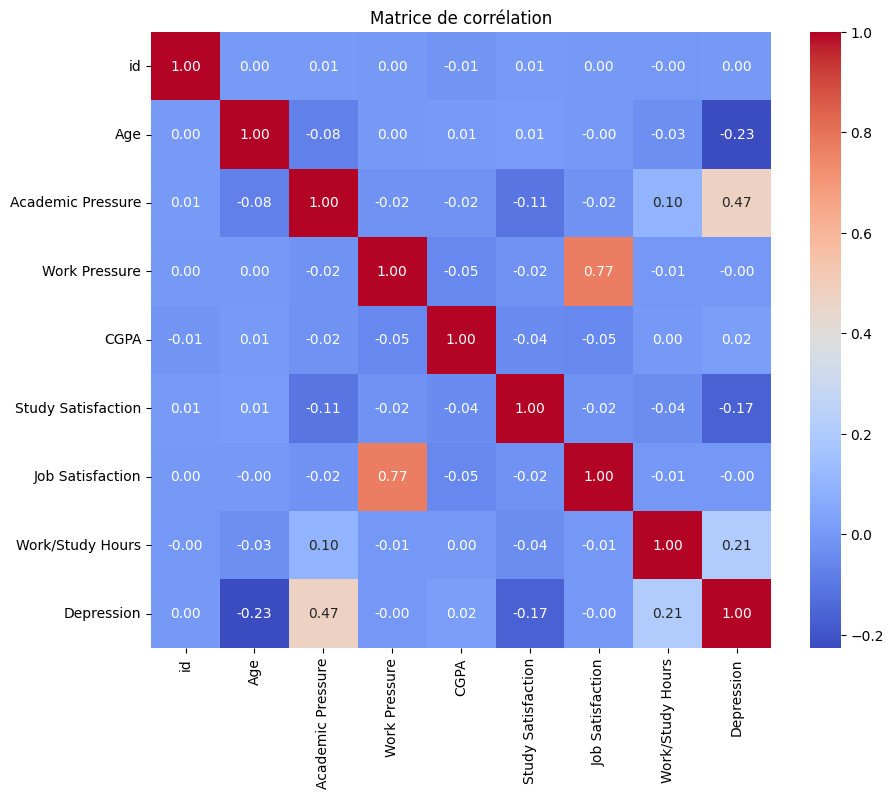

In [63]:
corr = df.select_dtypes(include=["int64","float64"]).corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation")

plt.show()

# Analyse multivariée

## Pairplot des principales variables numériques

### Objectif

Le pairplot permet de visualiser simultanément :

- la distribution de chaque variable numérique ;
- les relations entre les variables ;
- la répartition des classes de la variable cible (Depression).

Cette visualisation aide à détecter d'éventuelles corrélations, tendances ou séparations entre les étudiants dépressifs et non dépressifs avant la phase de modélisation.

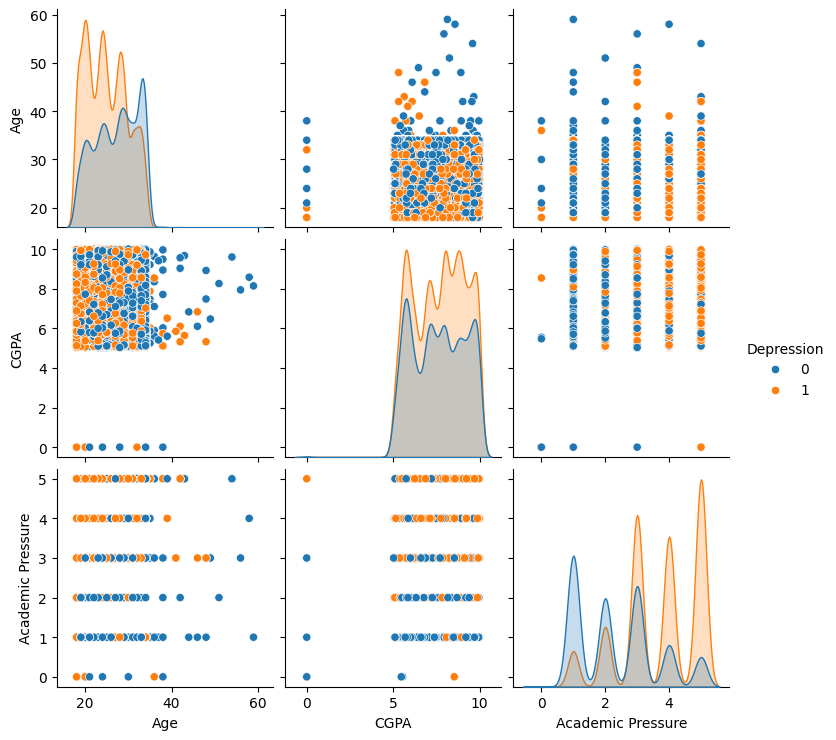

In [65]:
sns.pairplot(
    df[
        [
            "Age",
            "CGPA",
            "Academic Pressure",
            "Financial Stress",
            "Depression"
        ]
    ],
    hue="Depression"
)

##  Interprétation générale

Le pairplot montre que les variables **Age** et **CGPA** ne permettent pas de distinguer clairement les étudiants dépressifs des étudiants non dépressifs.

En revanche, la variable **Academic Pressure** présente une différence plus marquée entre les deux groupes. Les étudiants souffrant de dépression semblent plus nombreux à déclarer un niveau élevé de pression académique.

Ces observations confirment l'intérêt de conserver cette variable pour la phase de modélisation.

<Axes: xlabel='Depression', ylabel='Academic Pressure'>

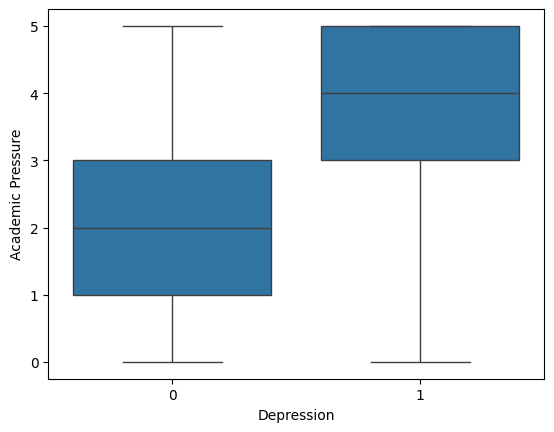

In [66]:
sns.boxplot(
    data=df,
    x="Depression",
    y="Academic Pressure"
)

<Axes: xlabel='Depression', ylabel='Financial Stress'>

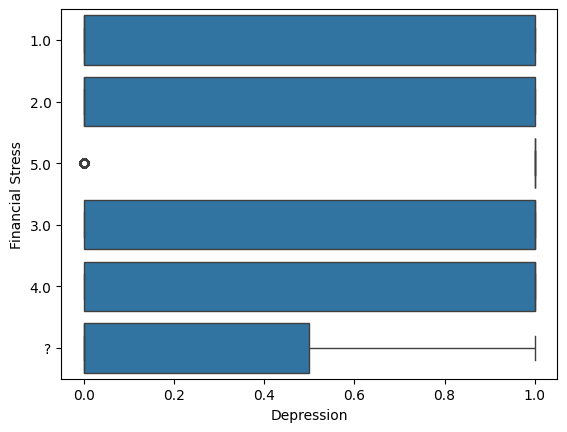

In [67]:
sns.boxplot(
    data=df,
    x="Depression",
    y="Financial Stress"
)


#  Test du Khi-deux (Chi²)

## Objectif

Le test du Khi-deux permet de vérifier s'il existe une association statistiquement significative entre deux variables catégorielles.

Dans ce projet, il est utilisé pour déterminer si certaines variables explicatives (Academic Pressure, Sleep Duration, Financial Stress, etc.) sont associées à la variable cible **Depression**.

Le test ne permet pas d'établir une relation de causalité, mais uniquement de déterminer si les deux variables sont statistiquement dépendantes.

In [68]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df["Academic Pressure"],
    df["Depression"]
)

chi2, p, ddl, expected = chi2_contingency(table)

print("Chi² :", chi2)
print("p-value :", p)
print("Degrés de liberté :", ddl)

Chi² : 6427.249219373416
p-value : 0.0
Degrés de liberté : 5


##  Interprétation

La p-value obtenue est largement inférieure au seuil de signification de 5 % (0,05).

Nous rejetons donc l'hypothèse nulle d'indépendance.

Ces résultats indiquent qu'il existe une association statistiquement significative entre la pression académique et la dépression.

Cette variable apparaît comme un facteur pertinent à conserver pour la phase de modélisation.

#  Conclusion générale de l'Analyse Exploratoire des Données (EDA)

L'analyse exploratoire des données a permis d'obtenir une meilleure compréhension du jeu de données et de vérifier sa qualité avant la phase de préparation des données et de modélisation.

Dans un premier temps, l'évaluation de la qualité des données a montré que le dataset ne contient aucune valeur manquante détectée par les fonctions classiques de Pandas et aucun doublon. Toutefois, une valeur particulière (`?`) a été identifiée dans la variable **Financial Stress**. Cette modalité sera considérée comme une valeur manquante et traitée lors de la phase de préparation des données.

L'analyse univariée a ensuite permis d'étudier la distribution des principales variables du jeu de données. Les résultats montrent que la population est principalement composée de jeunes étudiants âgés de 18 à 35 ans. Les variables **Academic Pressure**, **Financial Stress**, **Study Satisfaction** et **Have you ever had suicidal thoughts ?** présentent des distributions variées susceptibles d'apporter une information pertinente pour la prédiction de la dépression.

L'analyse bivariée a mis en évidence plusieurs relations intéressantes entre les variables explicatives et la variable cible **Depression**. En particulier, une augmentation de la pression académique semble être associée à une proportion plus importante d'étudiants souffrant de dépression, tandis qu'un niveau élevé de satisfaction des études paraît être associé à un risque plus faible de dépression. Ces observations suggèrent que plusieurs facteurs académiques et personnels peuvent influencer l'état psychologique des étudiants.

L'analyse multivariée, complétée par le pairplot, la matrice de corrélation et les tests statistiques (test du Khi-deux), a permis de confirmer que certaines variables présentent une association statistiquement significative avec la variable cible. Ces résultats orientent naturellement le choix des variables qui seront utilisées lors de la construction des modèles de Machine Learning.

Dans l'ensemble, cette phase d'analyse exploratoire montre que le jeu de données est de bonne qualité et qu'il contient des informations pertinentes pour développer un modèle de prédiction de la dépression chez les étudiants. Les connaissances acquises au cours de cette étape serviront de base à la prochaine phase du projet, consacrée à la préparation des données (Data Preparation), au cours de laquelle les données seront nettoyées, transformées et préparées pour l'entraînement et l'évaluation des modèles de Machine Learning.